<a href="https://colab.research.google.com/github/borysovamaryna/Sales-Analytics/blob/main/Sales_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --upgrade google-cloud-bigquery

In [ ]:
from google.colab import auth
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

In [ ]:
auth.authenticate_user()

In [ ]:
client = bigquery.Client(project="data-analytics-mate")

In [ ]:
query = """
SELECT DISTINCT
s.date,
s.ga_session_id,
sp.continent,
sp.country,
sp.device,
sp.browser,
sp.mobile_model_name,
sp.operating_system,
sp.language,
sp.name as traffic_source,
sp.channel,
acs.account_id,
ac.is_verified,
ac.is_unsubscribed,
p.category,
p.name,
p.price,
p.short_description
FROM `DA.session` s
join `DA.session_params` sp
on s.ga_session_id = sp.ga_session_id
left join `DA.account_session` acs
on acs.ga_session_id = sp.ga_session_id
left join `DA.account` ac
on ac.id = acs.account_id
left join `DA.order` o
on s.ga_session_id = o.ga_session_id
left join `DA.product` p
on o.item_id = p.item_id
"""

In [ ]:
query_job = client.query(query)
results = query_job.result()

In [ ]:
df = results.to_dataframe()

In [ ]:
df.head()

,date,ga_session_id,continent,country,device,browser,mobile_model_name,operating_system,language,traffic_source,channel,account_id,is_verified,is_unsubscribed,category,name,price,short_description
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,(organic),Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(direct),Direct,<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(direct),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(direct),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   date               349545 non-null  dbdate 
 1   ga_session_id      349545 non-null  Int64  
 2   continent          349545 non-null  object 
 3   country            349545 non-null  object 
 4   device             349545 non-null  object 
 5   browser            349545 non-null  object 
 6   mobile_model_name  349545 non-null  object 
 7   operating_system   349545 non-null  object 
 8   language           235279 non-null  object 
 9   traffic_source     349545 non-null  object 
 10  channel            349545 non-null  object 
 11  account_id         27945 non-null   Int64  
 12  is_verified        27945 non-null   Int64  
 13  is_unsubscribed    27945 non-null   Int64  
 14  category           33538 non-null   object 
 15  name               33538 non-null   object 
 16  pr

In [ ]:
print(f'Кількість унікальних сесій {df['ga_session_id'].nunique()}')
print(f'Період аналізу від {df['date'].min()} до {df['date'].max()}')
print(f'Кількість унікальних категорій {df['category'].nunique()}')
print(f'Кількість континентів {df['continent'].nunique()}')
print(f'Кількість країн {df['country'].nunique()}')
print(df['category'].unique())

Кількість унікальних сесій 349545
Період аналізу від 2020-11-01 до 2021-01-31
Кількість унікальних категорій 14
Кількість континентів 6
Кількість країн 108
['Bookcases & shelving units' 'Tables & desks' 'Cabinets & cupboards'
 'Bar furniture' None 'Chairs' 'Sofas & armchairs' 'Outdoor furniture'
 'Beds' "Children's furniture" 'Chests of drawers & drawer units'
 'Room dividers' 'Sideboards, buffets & console tables' 'Café furniture'
 'Nursery furniture']


## Результат запиту:

За написаним вище запитом ми отримали датасет для подальшого аналізу з наступними характеристиками:

- загальна кількість колонок 18;
- маємо 5 колонок числового типу, а саме:
   1. ідентифікатор сесії
   2. ідентифікатор акаунту
   3. чи підтвердив користувач свій  email (якщо так, то 1, якщо ні то 0)
   4. чи підписався користувач на email розсилку (якщо так, то 0, якщо ні то 1)
   5. ціна товару


- отримали 12 колонок категоріального типу, а саме:

   1. континент
   2. країна
   3. девайс
   4. браузер
   5. назва моделі пристрою
   6. операційна система
   7. мова браузера
   8. інформація про джерело трафіку
   9. канал трафіку
   10. категорія товару
   11. назва товару
   12. короткий опис товару

- отримали одну колошку типу datetime, а саме - дата;

- кількість унікальних сесій 349545;

- період аналізу від 2020-11-01 до 2021-01-31;

- ми маємо користувачів з 6 континентів та 108 різних країн;

- компанія реалізує продукцію 14 різних категорій, а саме:
     - Bookcases & shelving units,
     - Tables & desks,  
     - Cabinets & cupboards,
     - Bar furniture,
     - Chairs,
     - Sofas & armchairs,
     - Outdoor furniture,
     - Beds,
     - Children's furniture,
     - Chests of drawers & drawer units,
     - Room dividers,
     - Sideboards, buffets & console tables,
     - Café furniture,
     - Nursery furniture

- розглянувши інформацію по нашому датафрейму, ми бачимо, що маємо пропущені значення:
   1. пропущення значень в колонці мови,  з 349545 заповнено 235279, тобто пропущено 114266 значень, це могло бути через користувацькі налаштування (наприклад користувацькі обмеження, налаштування браузерів, або cookie)
   2. пропущені дані по колонкам ідентифікатор акаунту, чи підтверджено email і чи дано дозвіл на розсилку - причиною цього є те, що не всі користувачі системи є зареєстрованими, але оскільки ми бачимо що по всім зареєстрованим користувачам є інформація про email, то можемо сказати, що дані повні
   3. пропущені дані в колонках категорія, назва товару, ціна та короткий опис - це нам говорить про те, що не при кожній сесії було проведено покупку товару, але оскільки ми бачимо, що по всім даним колонкам заповнено однакову кількість рядків, то можемо сказати, що інфомацію доцільно вважати повною.





In [ ]:
top3_continent_sales = df.groupby('continent')['price'].sum().sort_values(ascending=False).head(3) #ТОП-3 континента по продажам
print(top3_continent_sales)

continent
Americas    17665280.0
Asia         7601298.3
Europe       5934624.2
Name: price, dtype: float64


In [ ]:
top3_continent_orders = df.groupby('continent')['ga_session_id'].count().sort_values(ascending=False).head(3) #ТОП-3 континента по замовленням
print(top3_continent_orders)

continent
Americas    193179
Asia         83113
Europe       65135
Name: ga_session_id, dtype: Int64


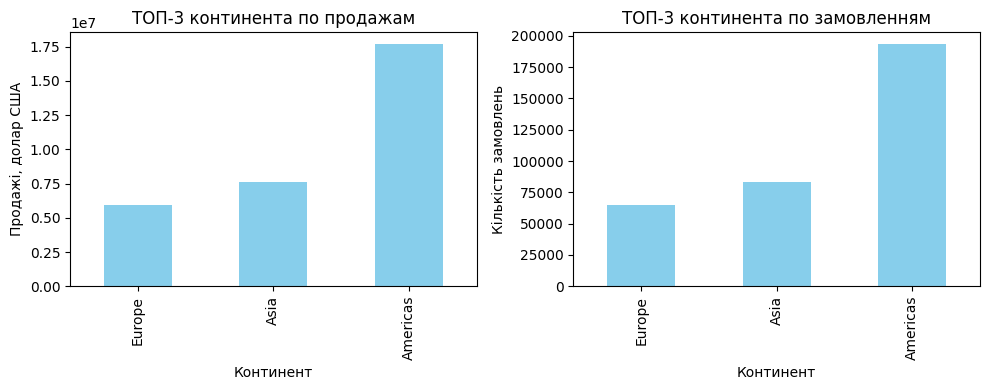

In [ ]:

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# First subplot - Device share
top3_continent_sales.sort_values().plot(kind='bar', ax=ax[0], color="skyblue")

ax[0].set_title('ТОП-3 континента по продажам')
ax[0].set_xlabel('Континент')
ax[0].set_ylabel('Продажі, долар США')

# Second subplot - Model share
top3_continent_orders.sort_values().plot(kind='bar', ax=ax[1], color="skyblue")

ax[1].set_title('ТОП-3 континента по замовленням')
ax[1].set_xlabel('Континент')
ax[1].set_ylabel('Кількість замовлень')

plt.tight_layout()
plt.show()

In [ ]:
top5_country_sales = df.groupby('country')['price'].sum().sort_values(ascending=False).head(5) #ТОП-5 країн по продажам
print(top5_country_sales)

country
United States     13943553.9
India              2809762.0
Canada             2437921.0
United Kingdom      938317.9
France              710692.8
Name: price, dtype: float64


In [ ]:
top5_country_orders = df.groupby('country')['ga_session_id'].count().sort_values(ascending=False).head(5) #ТОП-5 країн по замовленням
print(top5_country_orders)

country
United States     153470
India              32763
Canada             25994
United Kingdom     11003
France              6958
Name: ga_session_id, dtype: Int64


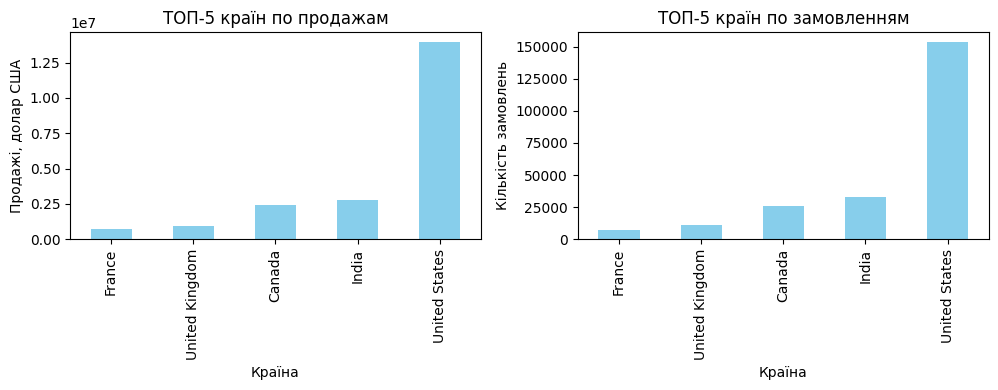

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# First subplot - Device share
top5_country_sales.sort_values().plot(kind='bar', ax=ax[0], color="skyblue")

ax[0].set_title('ТОП-5 країн по продажам')
ax[0].set_xlabel('Країна')
ax[0].set_ylabel('Продажі, долар США')

# Second subplot - Model share
top5_country_orders.sort_values().plot(kind='bar', ax=ax[1], color="skyblue")

ax[1].set_title('ТОП-5 країн по замовленням')
ax[1].set_xlabel('Країна')
ax[1].set_ylabel('Кількість замовлень')

plt.tight_layout()
plt.show()

In [ ]:
top10_category = df.groupby('category')['price'].sum().sort_values(ascending=False).head(10) #ТОП-10 категорій товарів за сумою продажів
print(top10_category)

category
Sofas & armchairs                   8388254.5
Chairs                              6147748.8
Beds                                4919725.0
Bookcases & shelving units          3640818.1
Cabinets & cupboards                2336499.5
Outdoor furniture                   2142222.2
Tables & desks                      1790307.5
Chests of drawers & drawer units     906562.5
Bar furniture                        735503.0
Children's furniture                 467697.0
Name: price, dtype: float64


In [ ]:
top_country = df.groupby('country')['price'].sum().idxmax()

top10_category_top5_country = df[df['country'] == top_country].groupby('category')['price'].sum().sort_values(ascending=False).head(10)
print(top10_category_top5_country)


category
Sofas & armchairs                   3707144.5
Chairs                              2619773.8
Beds                                2213058.0
Bookcases & shelving units          1567606.9
Cabinets & cupboards                 994545.5
Outdoor furniture                    929245.2
Tables & desks                       777865.0
Chests of drawers & drawer units     382388.0
Bar furniture                        330805.0
Children's furniture                 207575.0
Name: price, dtype: float64


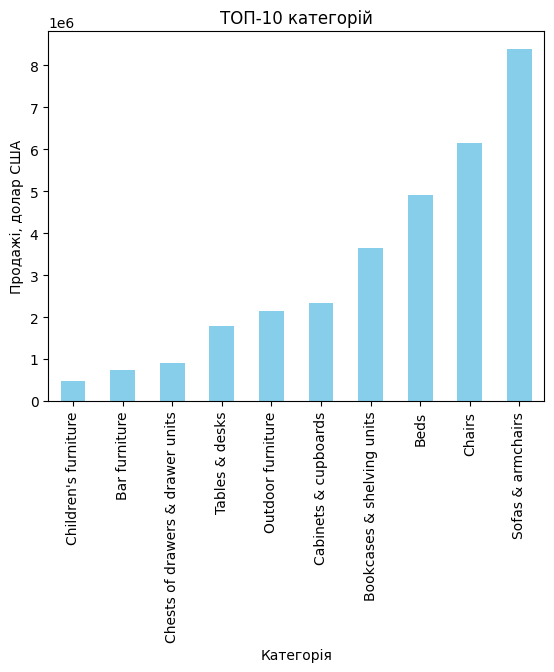

In [ ]:
top10_category.sort_values().plot(kind='bar', color="skyblue")
plt.title("ТОП-10 категорій")
plt.xlabel("Категорія")
plt.ylabel("Продажі, долар США")
plt.show()

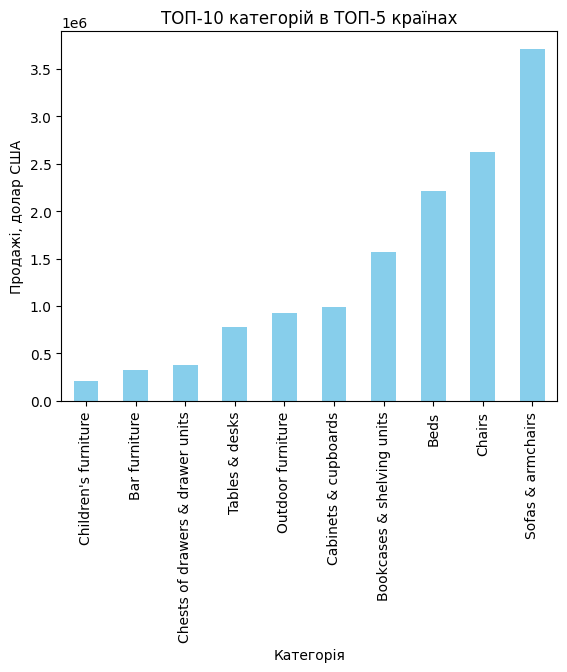

In [ ]:
top10_category_top5_country.sort_values().plot(kind='bar', color="skyblue")
plt.title("ТОП-10 категорій в ТОП-5 країнах")
plt.xlabel("Категорія")
plt.ylabel("Продажі, долар США")
plt.show()

##ТОП-3 континента та ТОП-5 країн по продажам ми бачимо в такому вигляді як:

 **1 місце** - Північна Америка:

      - США - 1 місце
      - Канада - 3 місце

 **2 місце** - Азія:

      - Індія - 2 місце

 **3 місце** - Європа:

      - Сполучене Королівство - 4 місце
      - Франція - 5 місце

За даними розрахунками, ми бачимо, що країною з найбільшими продажами стала США. При аналізі ТОП-10 категорій по продажам загалом по компанії і по США, ми бачимо однаковий перелік категорій та однакову послідовність, тобто можемо сказати, що в країні з найбільшими продажами така саме тенденція по категоріям продажів, як і вцілому по компанії.

## ТОП-10 категорій:
1. Дивани та крісла
2. Стільці
3. Ліжка
4. Книжкові шафи та стелажі
5. Шафи та комоди
6. Садові меблі
7. Столи та парти
8. Комоди та комоди
9. Барні меблі
10. Дитячі меблі



In [ ]:
# загальний дохід
total_sales = df['price'].sum()

# по девайсам
device_sales = df.groupby('device')['price'].sum()

# у %
device_share = (device_sales / total_sales) * 100

print(device_share.sort_values(ascending=False))

device
desktop    59.002245
mobile     38.734924
tablet      2.262831
Name: price, dtype: float64


In [ ]:
model_sales = df.groupby('mobile_model_name')['price'].sum()

model_share = (model_sales / total_sales) * 100
print(model_share.sort_values(ascending=False))

mobile_model_name
Chrome        27.835602
<Other>       20.440966
Safari        20.302504
iPhone        20.082667
ChromeBook     5.725241
Edge           2.180746
iPad           1.403910
Firefox        1.316998
Pixel 4 XL     0.369976
Pixel 3        0.341390
Name: price, dtype: float64


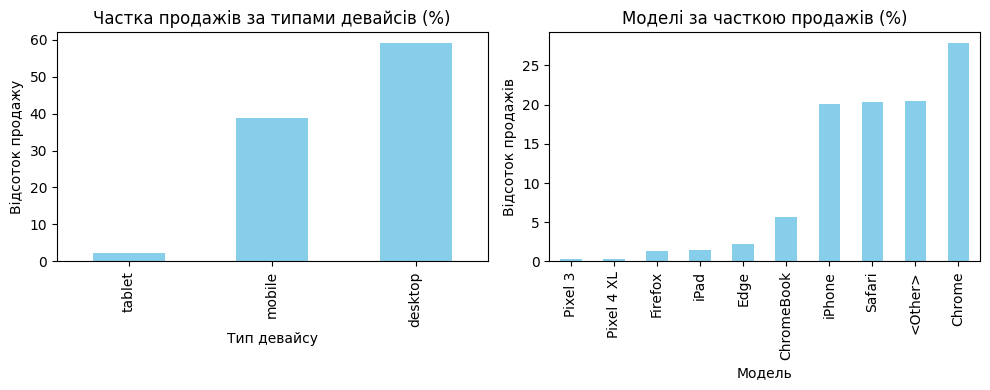

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# First subplot - Device share
device_share.sort_values().plot(kind='bar', ax=ax[0], color="skyblue")

ax[0].set_title('Частка продажів за типами девайсів (%)')
ax[0].set_xlabel('Тип девайсу')
ax[0].set_ylabel('Відсоток продажу')

# Second subplot - Model share
model_share.sort_values().head(10).plot(kind='bar', ax=ax[1], color="skyblue")

ax[1].set_title('Моделі за часткою продажів (%)')
ax[1].set_xlabel('Модель')
ax[1].set_ylabel('Відсоток продажів')

plt.tight_layout()
plt.show()

За розрахунками то частці продажів через різні типи та моделі девайсів можемо сказати, що найбільше продажів проводиться через decstop, а найменше через tabletю Розглядаючи моделі то найбільше продажів проводиться через браузер Chrome, інші моделі та Safari, при цьому найменше купують користувачі використовуючи Pixel 3ї та 4ї версії і користувачі через Firefox.

In [ ]:
# по джерелам трафіку
traffic_source_sales = df.groupby('traffic_source')['price'].sum()

# у %
traffic_source_share = (traffic_source_sales / total_sales) * 100

print(traffic_source_share.sort_values(ascending=False))

traffic_source
(organic)         34.202840
(direct)          23.442345
<Other>           18.445594
(referral)        17.646386
(data deleted)     6.262836
Name: price, dtype: float64


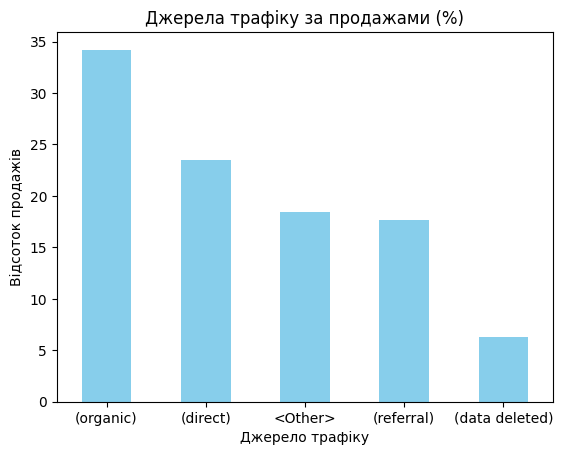

In [ ]:
traffic_source_share.sort_values(ascending=False).plot(kind='bar', color="skyblue")

plt.title('Джерела трафіку за продажами (%)')
plt.xlabel('Джерело трафіку')
plt.ylabel('Відсоток продажів')

plt.xticks(rotation=360)
plt.show()

Розрахувавши розподіл джерел трафіку за продажами, ми бачимо, що найбільше продажу відбулось через органічний канал звязку, а найменше серед тих, де канал було видалено

In [ ]:
print(f'Відсоток зареєстрованих користувачів, які підтвердили свою електронну адресу складає: {df['is_verified'].sum() / df['account_id'].nunique() * 100}%')
print(f'Відсоток зареєстрованих користувачів, які відписались від розсилки складає: {df['is_unsubscribed'].sum() / df['account_id'].nunique() * 100}%')


Відсоток зареєстрованих користувачів, які підтвердили свою електронну адресу складає: 71.69797817140812%
Відсоток зареєстрованих користувачів, які відписались від розсилки складає: 16.94399713723385%


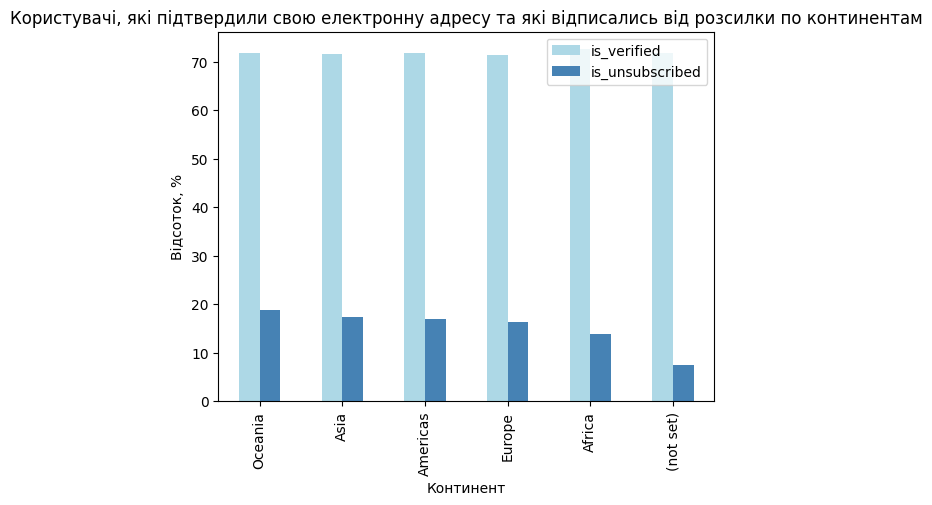

In [ ]:
continent_stats = df.groupby('continent').agg({
    'is_verified': 'mean',
    'is_unsubscribed': 'mean'
}) * 100
continent_stats = continent_stats.sort_values('is_unsubscribed', ascending=False)
continent_stats.plot(
    kind='bar',
    color=['lightblue', 'steelblue']
)
plt.title('Користувачі, які підтвердили свою електронну адресу та які відписались від розсилки по континентам')
plt.ylabel('Відсоток, %')
plt.xlabel('Континент')
plt.show()

In [ ]:
print(df.groupby('is_unsubscribed')['price'].sum())


is_unsubscribed
0    2150796.9
1     431721.6
Name: price, dtype: float64


Розглянувши співвідносшення користувачів які підтвердили свою елетконну пошту до тих, які відписались від розсилки в розрізі континентів, ми бачимо, що найбільше користувачів, які відписались в Океанії, а найменше в Африці.
Оскільки, ми знаємо, що в полі is_unsubscribed -  1 проставляється, якщо користувач відписався від россилки, а 0, якщо не відписувався, саме тому можемо сказати, що продажі серед тих, що відписались склали 432 тис доларів, а серед тих, що досі підписані продажі складають 2млн 151тис доларів, саме тому можемо сказати, що більш активно купують підписані користувачі.


In [ ]:
account_by_country = df.groupby('country')['account_id'].count()

print(account_by_country.sort_values(ascending=False))

country
United States        12384
India                 2687
Canada                2067
United Kingdom         859
France                 553
                     ...  
Honduras                 4
Paraguay                 4
Mongolia                 4
Trinidad & Tobago        4
Bahrain                  2
Name: account_id, Length: 108, dtype: Int64


In [ ]:
account_by_country_persent = (df.groupby('country')['account_id'].count() / df['account_id'].nunique()) * 100

print(account_by_country_persent.sort_values(ascending=False))

country
United States        44.31562
India                9.615316
Canada               7.396672
United Kingdom       3.073895
France               1.978887
                       ...   
Honduras             0.014314
Paraguay             0.014314
Mongolia             0.014314
Trinidad & Tobago    0.014314
Bahrain              0.007157
Name: account_id, Length: 108, dtype: Float64


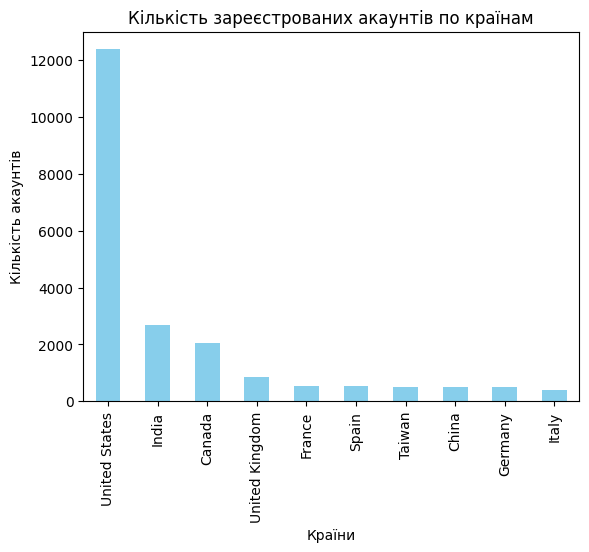

In [ ]:
account_by_country.sort_values(ascending=False).head(10).plot(kind='bar', color="skyblue")

plt.title('Кількість зареєстрованих акаунтів по країнам')
plt.xlabel('Країни')
plt.ylabel('Кількість акаунтів')

plt.xticks()
plt.show()

Розрахувавши кількість зареєстрованих акаунтів по країнам ТОП-10 виглядає наступним чином:
1. United States
2. India
3. Canada  
4. United Kingdom
5. France
6. Spain
7. Taiwan
8. China
9. Germany
10. Italy

При цьому можемо сказати, що ТОП-5 країн за продажами повністю відповідають ТОП-5 країн по зареєстрованим акаунтам. Також слід зазначити, що 2 країни мають більше половини зареєстрованих акаунтів, це США, яка має 44,3% з усіх користувачів з зареєстрованими акаунтами та Індія, яка має 9,6% зареєстрованих користувачів з усіх.


In [ ]:
print(df.groupby('date')['price'].sum())

date
2020-11-01    244292.5
2020-11-02    355506.8
2020-11-03    498979.6
2020-11-04    339187.1
2020-11-05    391276.6
                ...   
2021-01-27    286340.7
2021-01-28         0.0
2021-01-29         0.0
2021-01-30         0.0
2021-01-31         0.0
Name: price, Length: 92, dtype: float64


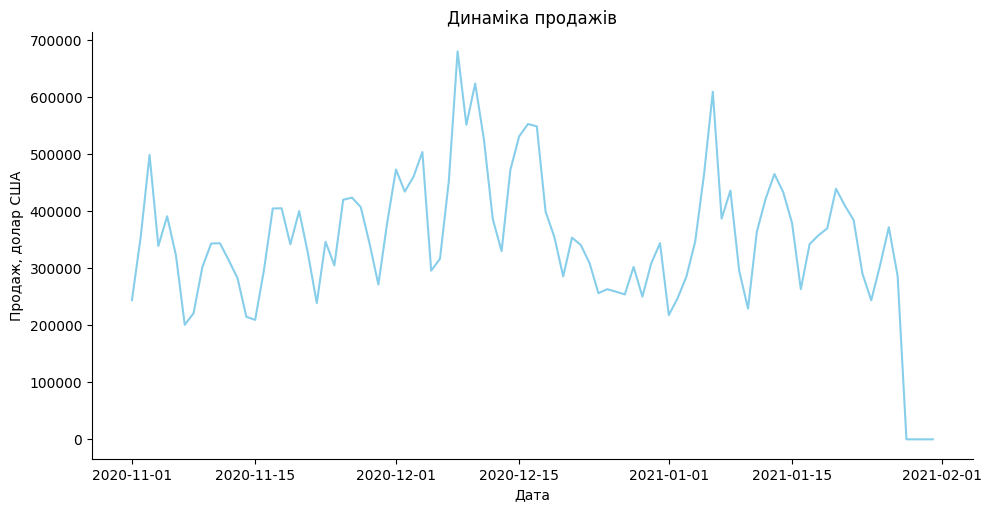

In [ ]:
sales_by_date = df.groupby('date')['price'].sum().reset_index()

sns.relplot(
    x="date",
    y="price",
    kind="line",
    data=sales_by_date,
    color='skyblue',
    #hue="region",
    #palette="rocket",
    aspect=2
)
plt.title("Динаміка продажів")
plt.xlabel("Дата")
plt.ylabel("Продаж, долар США")
plt.show()

In [ ]:
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')
df.groupby(df['date'].dt.to_period('M'))['price'].sum()

,price
date,
2020-11,9897515.0
2020-12,12423439.3
2021-01,9650776.8


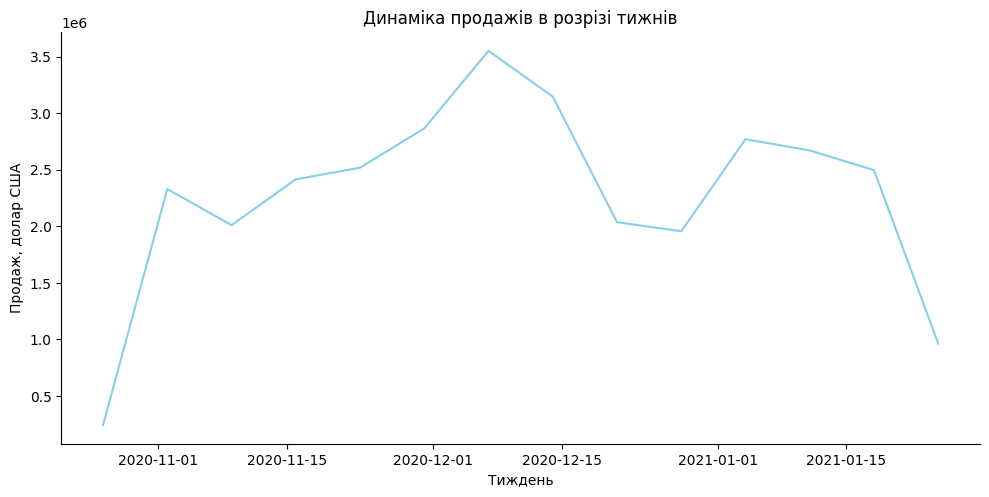

In [ ]:
df['date'] = pd.to_datetime(df['date'])

sales_by_week = df.groupby(df['date'].dt.to_period('W'))['price'].sum().reset_index()
sales_by_week['date'] = sales_by_week['date'].dt.to_timestamp()
sns.relplot(
    x="date",
    y="price",
    kind="line",
    data=sales_by_week,
    color='skyblue',
    aspect=2
)
plt.title("Динаміка продажів в розрізі тижнів")
plt.xlabel("Тиждень")
plt.ylabel("Продаж, долар США")
plt.show()


Розглянувши динаміку продажів по дням, сезонність продажів виявити дуже важко, тому для більш детального аналізу я розрахувала динаміку продажу по тижням, і це зображено на графіку вище, а також по місяцям. Єдине де чітко прослідковується сезонність це в місяцях, оскільки ми бачимо різкий ріст продажів у грудні, це може бути повязане з зимовими святами, але для більш точних висновків нам потрібні дані за кілька років.

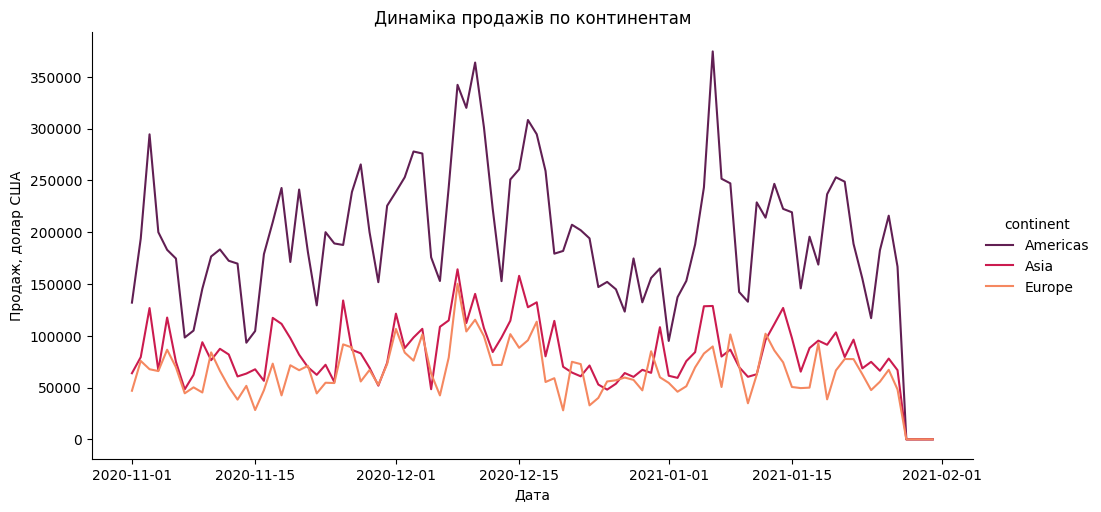

In [ ]:
continents = ['Americas', 'Asia', 'Europe']
sales_by_date = df[df['continent'].isin(continents)].groupby(["date", "continent"])['price'].sum().reset_index()

sns.relplot(
    x="date",
    y="price",
    kind="line",
    data=sales_by_date,
    hue="continent",
    palette="rocket",
    aspect=2
)
plt.title("Динаміка продажів по континентам Америка, Азія, Європа")
plt.xlabel("Дата")
plt.ylabel("Продаж, долар США")
plt.show()

За даним графіком ми бачимо, що динаміка продажів по континентам не має чіткої тенденції, оскільки є як збільшення так і падіння. При цьому можемо сказати, що в Америці продажі мають більше піків та більш різкі падіння. Оскільки за 1 день продажі можуть вирости на 200 тис доларів, або впасти на таку ж суму. Для виділення причин такої ситуації варто розглянути аналіз продажів для Америки по категоріям та по країнам.

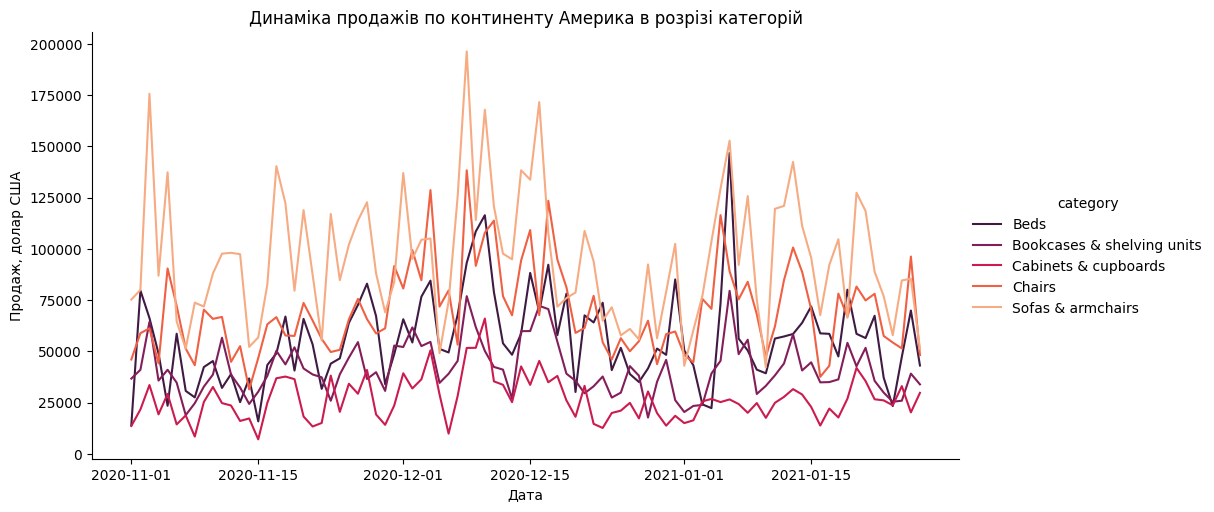

In [ ]:
continents = ['Americas']
filtered_df = df[df['continent'].isin(continents)]
top_categories = (
    filtered_df.groupby('category')['price']
    .sum()
    .nlargest(5)
    .index
)

sales_by_date_category = df[df['category'].isin(top_categories)].groupby(["date", "category"])['price'].sum().reset_index()

sns.relplot(
    x="date",
    y="price",
    kind="line",
    data=sales_by_date_category,
    hue="category",
    palette="rocket",
    aspect=2
)
plt.title("Динаміка продажів по континенту Америка в розрізі категорій")
plt.xlabel("Дата")
plt.ylabel("Продаж, долар США")
plt.show()

Отже, за графіком у розрізі категорій, а саме ТОП-5 категорій за продажами в Америці маємо, що найбільше на різкі зміни продажів впливає категорія Дивани та крісла, тому можно сказати, що попит на неє не є постійним і продажі змінюються з дня в день.

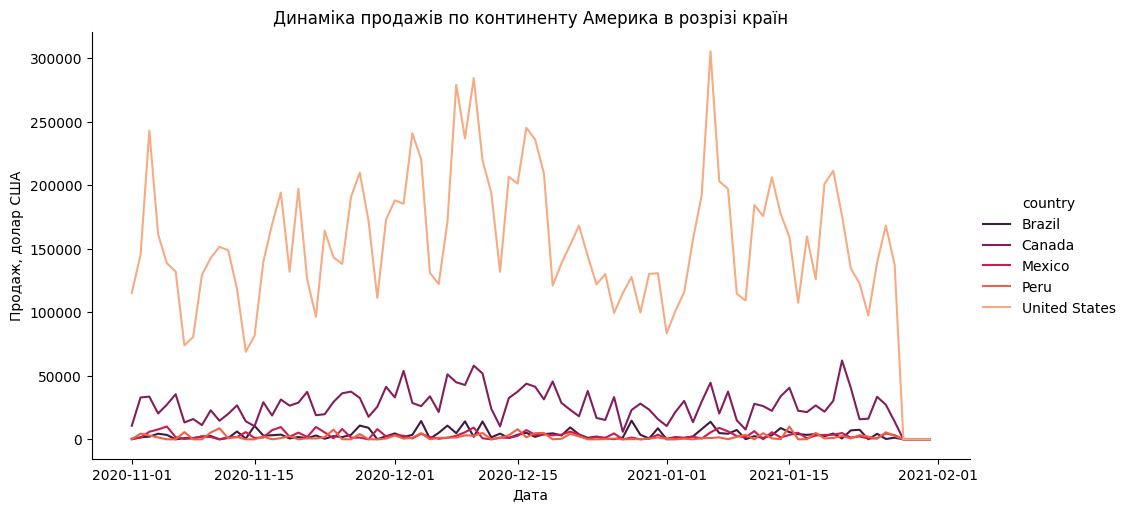

In [ ]:
continents = ['Americas']
filtered_df = df[df['continent'].isin(continents)]
top_country = (
    filtered_df.groupby('country')['price']
    .sum()
    .nlargest(5)
    .index
)

sales_by_date_country = df[df['country'].isin(top_country)].groupby(["date", "country"])['price'].sum().reset_index()

sns.relplot(
    x="date",
    y="price",
    kind="line",
    data=sales_by_date_country,
    hue="country",
    palette="rocket",
    aspect=2
)
plt.title("Динаміка продажів по континенту Америка в розрізі країн")
plt.xlabel("Дата")
plt.ylabel("Продаж, долар США")
plt.show()

За даним графіком ми бачимо, що найбільше продажів ми маємо в США при цьому слід зазначити, що спостерігається різке зменшення в період зимових свят, а саме після 15 грудня і наступний ріст продажів ми вже бачимо після Нового року.
При цьому інші країни Америки, а саме Канада, Мексика, Перу та Бразилія не мають таких різких змін у продажах.

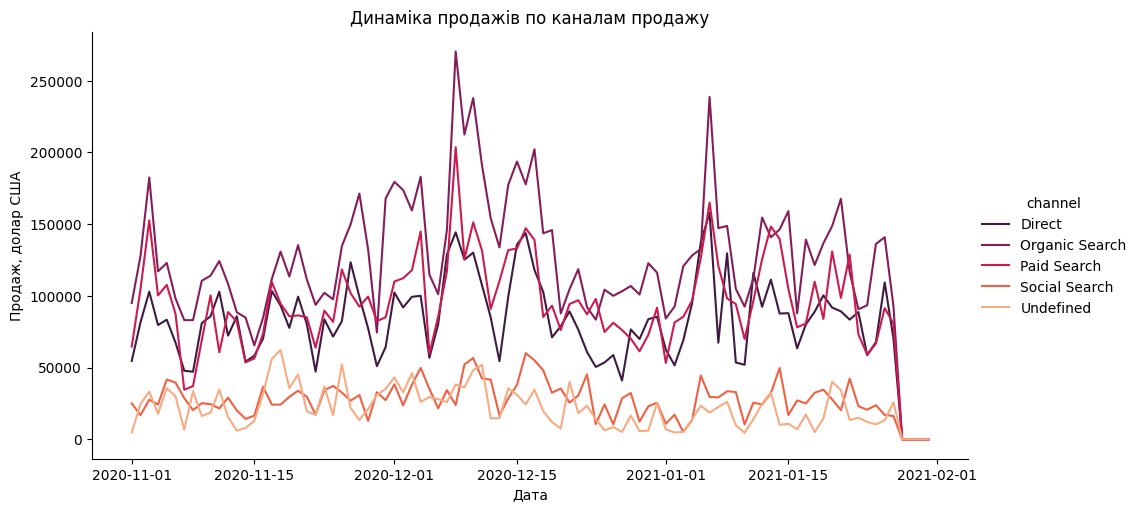

In [ ]:
sales_by_date_channel = df.groupby(["date", "channel"])['price'].sum().reset_index()

sns.relplot(
    x="date",
    y="price",
    kind="line",
    data=sales_by_date_channel,
    hue="channel",
    palette="rocket",
    aspect=2
)
plt.title("Динаміка продажів по каналам продажу")
plt.xlabel("Дата")
plt.ylabel("Продаж, долар США")
plt.show()

Аналізуючи динаміку продажів по каналам трафіку, ми бачимо, що найбільш нестабільні продажі здійснюються через Органічний канал, також різкі скачки по продажам є по каналу платного пошуку, і трішки менші стрибки дає канал дірект. Але слід зазначити, що графіки по даним каналам мають схожу тенденцію і в однакові дні мають зростання та падіння продажів. Тому можемо сказати, що канали трафіку не мають значного впливу на ріст або падіння продажів. При цьому можно сказати, що такі канали як Соціальні мережі та Невизначений канал не мають різких змін у досліджуваному періоді.

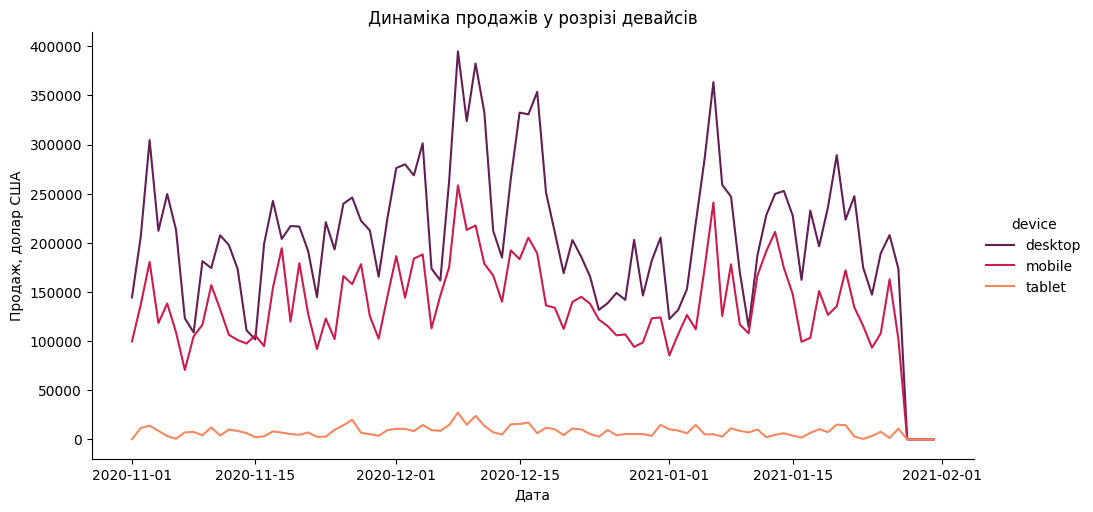

In [ ]:
sales_by_date_device = df.groupby(["date", "device"])['price'].sum().reset_index()

sns.relplot(
    x="date",
    y="price",
    kind="line",
    data=sales_by_date_device,
    hue="device",
    palette="rocket",
    aspect=2
)
plt.title("Динаміка продажів у розрізі девайсів")
plt.xlabel("Дата")
plt.ylabel("Продаж, долар США")
plt.show()

Проаналізувавши динаміки продажів у розрізі девайсів, ми бачимо, що найменше продажів відбувається для користувачів Планшетами, при цьому продажі є стабільними і не мають ні різких ростів ні різких падінь.
Найменш стабільні продажі спостеріються серед користувачів Декстоп. при цьому слід зауважити, що продажі по даному типу девайсів є найбльшими. Користувачі мобільними телефонами мають менш різкі зміни в продажах, але слід зазначити що піки продажів для користувачів декстоп майже повністю співпадають з піками продажів для користувачів планшетів, так само і падіння в продажах. Саме тому можемо сказати, що зміни в продажах між днями не залежать від типу девайсу.

In [ ]:
session_by_channel_device = filtered_df.pivot_table(
    index='channel',
    columns='device',
    values='ga_session_id',
    aggfunc='count',
    fill_value=0
)

print(session_by_channel_device )


device          desktop  mobile  tablet
channel                                
Direct             2992    1922     100
Organic Search     4461    2925     167
Paid Search        3350    2263     133
Social Search      1008     661      35
Undefined           726     534      30


In [ ]:
session_by_channel_device = filtered_df.pivot_table(
    index='channel',
    columns='device',
    values='ga_session_id',
    aggfunc='count',
    fill_value=0
)
percent = session_by_channel_device / session_by_channel_device.values.sum() * 100

print(percent)



device            desktop     mobile    tablet
channel                                       
Direct          14.042334    9.02051  0.469329
Organic Search  20.936781  13.727883   0.78378
Paid Search     15.722533  10.620923  0.624208
Social Search     4.73084   3.102267  0.164265
Undefined        3.407331   2.506219  0.140799


## Кількість сесій у розрізі каналів трафіку та типів девайсів

За інформацією в даній таблиці можемо сказати, що ТОП-3 кількості сесій  компанії виглядає так:
1. Декстопи в Органічному каналі звязку приносять нам 20.9% сессій від загальної кількості,
2. Декстопи у Платний канал приносять нам 15,7% сесій від загальної кількості
3. Мобільні телефони в Огранічному каналі приносять компанії 14% сесій

Також можемо сказати, що у розрізі каналів звязку набільше сесій нам приносить саме Органічний канал, на другому місці є Платний канал

In [ ]:
# Топ-10 категорій за продажами
top_categories = (
    df.groupby('category')['price']
    .sum()
    .nlargest(10)
    .index
)

# Топ-5 країн за продажами
top_countries = (
    df.groupby('country')['price']
    .sum()
    .nlargest(5)
    .index
)

# Фільтруємо дані
filtered_df = df[
    (df['category'].isin(top_categories)) &
    (df['country'].isin(top_countries))
]

# Зведена таблиця
sales_by_category_country = filtered_df.pivot_table(
    index='category',
    columns='country',
    values='price',
    aggfunc='sum',
    fill_value=0
)
sales_by_category_country = sales_by_category_country.loc[
    sales_by_category_country.sum(axis=1).sort_values(ascending=False).index
]
sales_by_category_country = sales_by_category_country[
    sales_by_category_country.sum(axis=0).sort_values(ascending=False).index
]
print(sales_by_category_country)

country                           United States     India    Canada  \
category                                                              
Sofas & armchairs                     3707144.5  788430.0  692427.5   
Chairs                                2619773.8  544309.2  417740.8   
Beds                                  2213058.0  358319.5  354772.0   
Bookcases & shelving units            1567606.9  364507.4  278981.9   
Cabinets & cupboards                   994545.5  191888.0  181802.0   
Outdoor furniture                      929245.2  162289.4  185322.8   
Tables & desks                         777865.0  186157.5  132678.0   
Chests of drawers & drawer units       382388.0   73111.0   71952.0   
Bar furniture                          330805.0   57657.0   51724.0   
Children's furniture                   207575.0   39177.0   30264.0   

country                           United Kingdom    France  
category                                                    
Sofas & armchairs        

## ТОП-10 категорій по продажам у ТОП-5 країнах по продажам

За даними розрахунками ми бачимо, що найбільше продаються такі категорії як:
Дивани та крісла, Стільці та Ліжка. При цьому найбільше продажів компанія має в таких країнах , США, Індія, Канада, Сполучено Королівство, Франція.

In [ ]:
df['is_registration'] = np.where(
    df['account_id'].isna(),
    'not registration',
    'is registration'
)
count_is_registration = df.groupby("is_registration")['ga_session_id'].count().reset_index()

print(count_is_registration)

    is_registration  ga_session_id
0   is registration          27945
1  not registration         321600


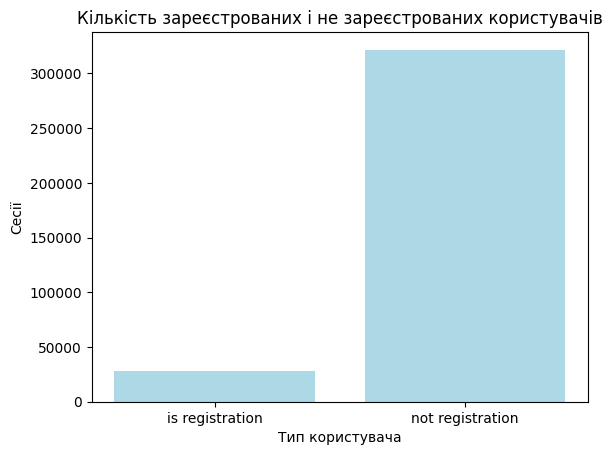

In [ ]:


plt.figure()
plt.bar(
    count_is_registration['is_registration'],
    count_is_registration['ga_session_id'],
    color='lightblue'
)

plt.title('Кількість зареєстрованих і не зареєстрованих користувачів')
plt.ylabel('Сесії')
plt.xlabel('Тип користувача')

plt.show()

In [ ]:
# Топ-10 країн за продажами
top_10_countries = (
    df.groupby('country')['price']
    .sum()
    .nlargest(10)
    .index
)

# Фільтруємо дані
filtered_df_country = df[df['country'].isin(top_10_countries)]

# Зведена таблиця
sales_by_country_registration = filtered_df_country.pivot_table(
    index='country',
    columns='is_registration',
    values='price',
    aggfunc='sum',
    fill_value=0
)
sales_by_country_registration = sales_by_country_registration.loc[
    sales_by_country_registration.sum(axis=1).sort_values(ascending=False).index
]
print(sales_by_country_registration)

is_registration  is registration  not registration
country                                           
United States          1100367.8        12843186.1
India                   207605.5         2602156.5
Canada                  192894.4         2245026.6
United Kingdom           65141.5          873176.4
France                   58508.0          652184.8
Spain                    51409.3          580137.4
Germany                  50546.5          548674.9
China                    38174.1          550155.5
Taiwan                   55984.0          496726.3
Singapore                65691.8          390755.4


In [ ]:
sales_by_country_registration = filtered_df_country.pivot_table(
    index='country',
    columns='is_registration',
    values='price',
    aggfunc='sum',
    fill_value=0
)
percent_country = sales_by_country_registration / sales_by_country_registration.values.sum() * 100
percent_country = percent_country.loc[
    percent_country.sum(axis=1).sort_values(ascending=False).index
]
print(percent_country)

is_registration  is registration  not registration
country                                           
United States           4.649081         54.262774
India                   0.877138         10.994175
Canada                  0.814984          9.485292
United Kingdom          0.275224          3.689192
France                  0.247198          2.755497
Spain                   0.217206          2.451095
Germany                 0.213560          2.318165
China                   0.161287          2.324420
Taiwan                  0.236534          2.098681
Singapore               0.277549          1.650951


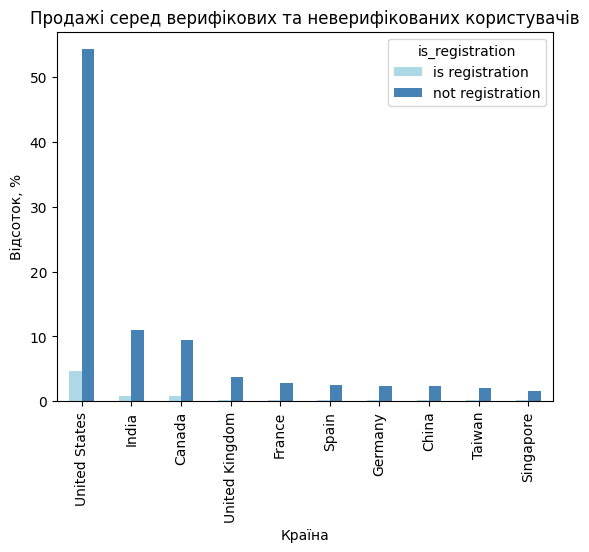

In [ ]:

percent_country.plot(
    kind='bar',
    color=['lightblue', 'steelblue']
)
plt.title('Продажі серед верифікових та неверифікованих користувачів')
plt.ylabel('Відсоток, %')
plt.xlabel('Країна')
plt.show()

## Розподіл продажів у ТОП-10 країнах серед зареєстрованих і не зареєстрованих користувачів

За даними розрахунками ми бачимо, що більшість продажів компанія здійснюю незареєстрованим користувачам. Також слід зазначити що найбільше продажів компанія отримує від незареєстрованих користувачів зі Сша, і це складає 54% від загальних продажів, зареєстровані 4,6%, при цьому незареєстровані користувачі з Індії дають 11% продажів, тоді як зареєстровані менше 1%.

In [ ]:
session_by_language_device = df.pivot_table(
    index='language',
    columns='device',
    values=['ga_session_id', 'price'],
    aggfunc={
        'ga_session_id': 'count',
        'price': 'sum'
    },
    fill_value=0
)

session_by_language_device = session_by_language_device.rename(
    columns={
        'ga_session_id': 'sessions',
        'price': 'sales'
    },
    level=0
)

sorted_index = session_by_language_device['sessions'].sum(axis=1).sort_values(ascending=False).index

session_by_language_device = session_by_language_device.loc[sorted_index]

print(session_by_language_device)



         sessions                    sales                     
device    desktop mobile tablet    desktop     mobile    tablet
language                                                       
en-us       93756  62661   3476  8691269.4  5711500.6  313100.2
en-gb       14404   9794    576  1258719.4   875520.9   47074.0
zh           7206   4724    292   646370.3   367541.3   39129.0
en           6685   4567    266   571537.1   413605.2   10394.6
en-ca        5471   3649    212   511491.6   253829.0   13532.0
es-es        3345   2268    147   327018.5   176284.6   11270.0
fr           3259   2259    134   342858.0   205001.9   31164.6
de           2061   1247     79   167952.1    88075.6    1061.0
ko           1590   1072     79   174049.4   115486.4    8993.0


##Розподіл кількості сесій та сум продажів між мовами та типами девайсів

Отже, за даними розрахунками ми бачимо, що серед всіх тип девайсів найчастіше клієнти користуваються американською та британською англійською, на третьому місці серед мов у нас китайська. дана тенденція у нас спостерігається по кількості сесій і по сумам продажів (окрім продажів через мобільні телефони, в даному випадку на третьому місці також англійська мова)
Найріжше по всім типам девайсів відкриваються сесії користувачами корейською мовою, при цьому продажів найменше серед користувачів німецькою мовою.
Також можемо сказати, що з даної таблички ми бачимо, що розподіл кількості сесій по мовам користувачів не повністю ідентичний з розподілом сум продажів по мовам у розрізі девайсів

In [ ]:
session_and_sales = (
    df.groupby("date")
    .agg(
        sessions=('ga_session_id', 'count'),
        sales=('price', 'sum')
    )
    .reset_index()
)

print(session_and_sales)

          date  sessions     sales
0   2020-11-01      2576  244292.5
1   2020-11-02      3599  355506.8
2   2020-11-03      5173  498979.6
3   2020-11-04      4184  339187.1
4   2020-11-05      3743  391276.6
..         ...       ...       ...
87  2021-01-27      4435  286340.7
88  2021-01-28      4112       0.0
89  2021-01-29      3700       0.0
90  2021-01-30      2845       0.0
91  2021-01-31      2812       0.0

[92 rows x 3 columns]


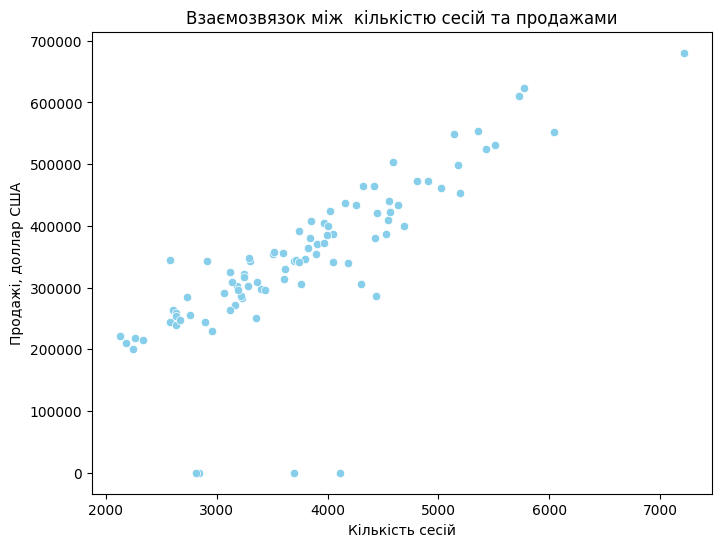

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=session_and_sales, x="sessions", y="sales", color='skyblue')
plt.title("Взаємозвязок між  кількістю сесій та продажами")
plt.xlabel("Кількість сесій")
plt.ylabel("Продажі, доллар США")
plt.show()

In [ ]:
from scipy.stats import normaltest
_, p_value_session = normaltest(session_and_sales['sessions'])
_, p_value_sales = normaltest(session_and_sales['sales'])

print(f"По Normaltest для отриманої вибірки сесій показник p-value: {p_value_session}")
print(f"По Normaltest для отриманої вибірки продажів показник p-value: {p_value_sales}")

По Normaltest для отриманої вибірки сесій показник p-value: 0.008655428822366544
По Normaltest для отриманої вибірки продажів показник p-value: 0.021085752302202193


In [ ]:


corr, p_value = spearmanr(
    session_and_sales['sessions'],
    session_and_sales['sales']
)

print(corr, p_value)

0.8653062174563682 9.755923586156614e-29


Отже, розглянувши графік взаємовзвязку між продажами та кількістю сесій ми бачимо, на ньому залежність показників. Тому можемо сказати, що продажі прямопропорційно залежать від кількості сесій.
Для подальшого аналізу кореляція спочатку перевіряємо вибірки на нормальність, оскільки в обох випадках ми отримали p-value які менші ніж 0,05. то для подальшої кореляції обираємо тест Спірмена, оскільки його можно застосовувати коли вибірки не є нормальними.
За тестом Спірмена ми отримали, що кореляція складає 0,86 -  тобто маємо сильно позитивну кореляцію, а оскільки p_value < 0,05 , можемо сказати, що наша кореляція є статистично значущою.

In [ ]:
top3_continent = df.groupby('continent')['price'].sum().nlargest(3).index

top3_continent_data = df[df['continent'].isin(top3_continent)]

pivot_date_continent = top3_continent_data.pivot_table(
    index='date',
    columns='continent',
    values='price',
    aggfunc='sum'
).fillna(0)

print(pivot_date_continent)


continent   Americas      Asia   Europe
date                                   
2020-11-01  132002.5   63823.0  46908.0
2020-11-02  193861.0   79370.0  75710.8
2020-11-03  294529.8  126737.8  67692.0
2020-11-04  200009.5   66602.0  65915.0
2020-11-05  182988.2  117608.4  86540.0
...              ...       ...      ...
2021-01-27  166735.5   66783.1  48156.1
2021-01-28       0.0       0.0      0.0
2021-01-29       0.0       0.0      0.0
2021-01-30       0.0       0.0      0.0
2021-01-31       0.0       0.0      0.0

[92 rows x 3 columns]


In [ ]:
pivot_date_continent.corr()
from scipy.stats import spearmanr

corr, p = spearmanr(
    pivot_date_continent['Europe'],
    pivot_date_continent['Asia']
)

print(corr, p)

0.6571102685039614 1.1290947217450973e-12


In [ ]:
corr, p = spearmanr(
    pivot_date_continent['Europe'],
    pivot_date_continent['Americas']
)

print(corr, p)

0.6725700545639509 2.1035588726455927e-13


In [ ]:
corr, p = spearmanr(
    pivot_date_continent['Asia'],
    pivot_date_continent['Americas']
)

print(corr, p)

0.7099016615801969 2.3233796296203977e-15


Отже, для аналізу кореляцій між продажами по континентам спочатку ми побудували зведену таблицю з даними продажами по датам. Далі аналізуємо кореляції між парами контенентів. За даними розрахунками, можно сказати, що:
1. Кореляція між Азією та Америкою є високою і позитивною, оскільки складає 0,71 при цьому p-value< 0,05, що вказує на статистичну значущисть результатів.
2. При цьому між Європою та Америкою є помірна позитивна кореляція, яка складає 0,67 і вона є статистично значущою оскільки p-value< 0,05
3. Кореляція між Європою та Азією є також помірною та позитивною, оскільки складає 0,66 і цей показник є статистично значущим, бо p-value< 0,05
Тобто можемо сказати, що динаміка продажів на континентах є майже синхронною, оскільки показники кореляції дуже близькі між собою.

In [ ]:
pivot_date_channel = df.pivot_table(
    index='date',
    columns='channel',
    values='price',
    aggfunc='sum'
).fillna(0)

print(pivot_date_channel)

channel       Direct  Organic Search  Paid Search  Social Search  Undefined
date                                                                       
2020-11-01   54669.5         95112.0      64688.0        25078.0     4745.0
2020-11-02   81561.5        127746.5     104780.8        16843.0    24575.0
2020-11-03  102909.5        182521.9     152641.3        27652.5    33254.4
2020-11-04   79683.6        117067.1     100332.0        24257.4    17847.0
2020-11-05   83367.6        122938.4     107648.0        41693.2    35629.4
...              ...             ...          ...            ...        ...
2021-01-27   70423.1         92921.1      80869.5        16282.0    25845.0
2021-01-28       0.0             0.0          0.0            0.0        0.0
2021-01-29       0.0             0.0          0.0            0.0        0.0
2021-01-30       0.0             0.0          0.0            0.0        0.0
2021-01-31       0.0             0.0          0.0            0.0        0.0

[92 rows x 

In [ ]:
corr_matrix_channel = pivot_date_channel.corr(method='spearman')
print(corr_matrix_channel)

channel           Direct  Organic Search  Paid Search  Social Search  \
channel                                                                
Direct          1.000000        0.779663     0.729369       0.469342   
Organic Search  0.779663        1.000000     0.793381       0.461543   
Paid Search     0.729369        0.793381     1.000000       0.492725   
Social Search   0.469342        0.461543     0.492725       1.000000   
Undefined       0.556922        0.524677     0.556491       0.462530   

channel         Undefined  
channel                    
Direct           0.556922  
Organic Search   0.524677  
Paid Search      0.556491  
Social Search    0.462530  
Undefined        1.000000  


In [ ]:

p_values_channel = pd.DataFrame(index=pivot_date_channel.columns, columns=pivot_date_channel.columns)

for col1 in pivot_date_channel.columns:
    for col2 in pivot_date_channel.columns:
        _, p = spearmanr(pivot_date_channel[col1], pivot_date_channel[col2])
        p_values_channel.loc[col1, col2] = p

print(p_values_channel)

channel           Direct Organic Search Paid Search Social Search Undefined
channel                                                                    
Direct               0.0            0.0         0.0      0.000002       0.0
Organic Search       0.0            0.0         0.0      0.000004       0.0
Paid Search          0.0            0.0         0.0      0.000001       0.0
Social Search   0.000002       0.000004    0.000001           0.0  0.000003
Undefined            0.0            0.0         0.0      0.000003       0.0


<Axes: xlabel='channel', ylabel='channel'>

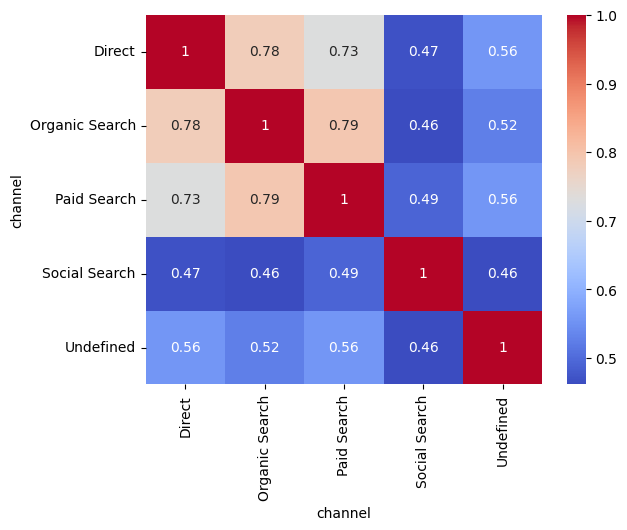

In [ ]:
sns.heatmap(corr_matrix_channel, annot=True, cmap='coolwarm')

Розрахувавши кореляції між каналами трафіку, ми отримали наступні результати:
1. Кореляції є високими та позитивними між такими каналами, як:
   - Direct - Organic Search
   - Direct - Paid Search
   - Organic Search - Paid Search
2. Кореляції є помірними та позитивними між такими каналами:
   - Direct - Social Search
   - Direct - Undefined
   - Paid Search - Social Search
   - Paid Search - Undefined
   - Organic Search - Social Search
   - Organic Search - Undefined
   - Social Search - Undefined

При цьому всі коефіцієнти є статистично значущими, оскільки по всім показникам p-value < 0,05

Найсильніші звязки ми спостерігаємо між Organic Search - Paid Search та Direct - Organic Search, це може світчити про маркетингову активність, або схожу політику компанії в даних каналах


In [ ]:
top5_categories = df.groupby('category')['price'].sum().nlargest(5).index

top5_categories_data = df[df['category'].isin(top5_categories)]

pivot_date_category = top5_categories_data.pivot_table(
    index='date',
    columns='category',
    values='price',
    aggfunc='sum'
).fillna(0)

print(pivot_date_category)


category       Beds  Bookcases & shelving units  Cabinets & cupboards  \
date                                                                    
2020-11-01  14041.0                     36701.0               13591.5   
2020-11-02  79683.5                     40979.0               21623.0   
2020-11-03  66219.5                     64360.1               33555.5   
2020-11-04  48939.0                     35719.8               19266.0   
2020-11-05  23449.0                     40998.8               29235.0   
...             ...                         ...                   ...   
2021-01-23  37116.0                     29862.7               26068.0   
2021-01-24  23294.0                     25396.0               23664.5   
2021-01-25  47303.5                     25919.6               33028.0   
2021-01-26  69894.5                     39119.2               20218.0   
2021-01-27  43080.0                     33874.2               29739.0   

category     Chairs  Sofas & armchairs  
date     

In [ ]:
corr_matrix_category = pivot_date_category.corr(method='spearman')
print(corr_matrix_category)

category                        Beds  Bookcases & shelving units  \
category                                                           
Beds                        1.000000                    0.542742   
Bookcases & shelving units  0.542742                    1.000000   
Cabinets & cupboards        0.440368                    0.528706   
Chairs                      0.534941                    0.636751   
Sofas & armchairs           0.521715                    0.625603   

category                    Cabinets & cupboards    Chairs  Sofas & armchairs  
category                                                                       
Beds                                    0.440368  0.534941           0.521715  
Bookcases & shelving units              0.528706  0.636751           0.625603  
Cabinets & cupboards                    1.000000  0.526822           0.631204  
Chairs                                  0.526822  1.000000           0.583319  
Sofas & armchairs                       0.6

In [ ]:
p_values_category = pd.DataFrame(index=pivot_date_category.columns, columns=pivot_date_category.columns)

for col1 in pivot_date_category.columns:
    for col2 in pivot_date_category.columns:
        _, p = spearmanr(pivot_date_category[col1], pivot_date_category[col2])
        p_values_category.loc[col1, col2] = p

print(p_values_category)

category                        Beds Bookcases & shelving units  \
category                                                          
Beds                             0.0                        0.0   
Bookcases & shelving units       0.0                        0.0   
Cabinets & cupboards        0.000018                        0.0   
Chairs                           0.0                        0.0   
Sofas & armchairs                0.0                        0.0   

category                   Cabinets & cupboards Chairs Sofas & armchairs  
category                                                                  
Beds                                   0.000018    0.0               0.0  
Bookcases & shelving units                  0.0    0.0               0.0  
Cabinets & cupboards                        0.0    0.0               0.0  
Chairs                                      0.0    0.0               0.0  
Sofas & armchairs                           0.0    0.0               0.0  


<Axes: xlabel='category', ylabel='category'>

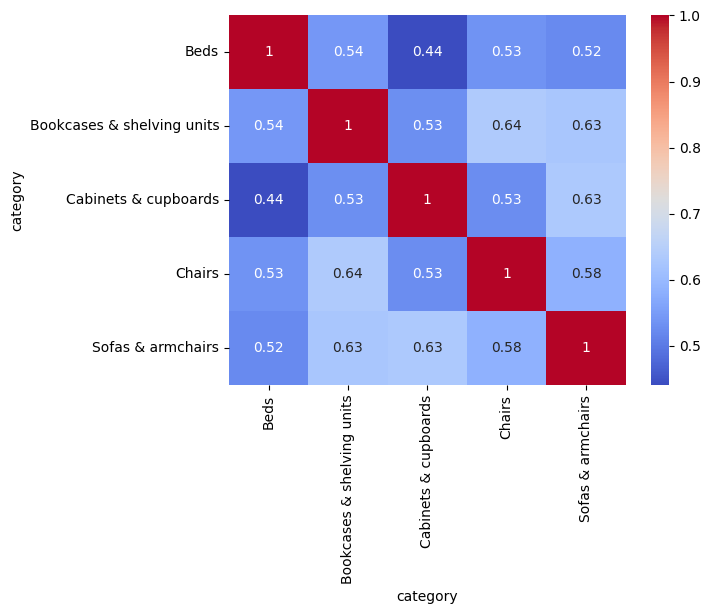

In [ ]:
sns.heatmap(corr_matrix_category, annot=True, cmap='coolwarm')

Отже, розглянувши розрахунки по кореляціям між ТОП-5 категорій, які продає компанія, ми бачимо, що всі категорії між собой мають помірну пряму кореляцію, тобто це світчить, що продажі рухаються в одному напрямку, при цьому звязок не є сильним та жорстким.
Це нам говорить, що категорії частково повязані між собою, і мають суміжний попит, але також і говорить нам що категорії не мають повної залежності між собою і мають свій власний розвиток.
Найбільше значення коефієнту зафіксовано між такими категоріями, як: Стільці та Книжкові шафи, що може свідчити про суміжний попит
Розглянувши значення p-value ми бачимо, що всі розрахунки є статистично значущими.

In [ ]:
top5_language = df.groupby('language')['price'].sum().nlargest(5).index

top5_language_data = df[df['language'].isin(top5_language)]

pivot_date_language = top5_language_data.pivot_table(
    index='date',
    columns='language',
    values='price',
    aggfunc='sum'
).fillna(0)

print(pivot_date_language)

language         en    en-ca    en-gb     en-us       zh
date                                                    
2020-11-01   9588.0   3149.0  38505.0   87432.0  18468.0
2020-11-02  11973.0   6661.5  16002.0  155493.0  14995.0
2020-11-03  43653.0  12776.0  28519.0  179740.0  27986.0
2020-11-04  14835.0   8413.5  34177.4  133362.2   8786.0
2020-11-05  11176.4   1985.0  20176.0  190042.0  11350.6
...             ...      ...      ...       ...      ...
2021-01-27   9094.0   4375.0  26915.0  129322.6   4023.0
2021-01-28      0.0      0.0      0.0       0.0      0.0
2021-01-29      0.0      0.0      0.0       0.0      0.0
2021-01-30      0.0      0.0      0.0       0.0      0.0
2021-01-31      0.0      0.0      0.0       0.0      0.0

[92 rows x 5 columns]


In [ ]:
corr_matrix_language = pivot_date_language.corr(method='spearman')
print(corr_matrix_language)

language        en     en-ca     en-gb     en-us        zh
language                                                  
en        1.000000  0.159284  0.477250  0.516785  0.302623
en-ca     0.159284  1.000000  0.230463  0.355113  0.214650
en-gb     0.477250  0.230463  1.000000  0.481627  0.359530
en-us     0.516785  0.355113  0.481627  1.000000  0.454871
zh        0.302623  0.214650  0.359530  0.454871  1.000000


In [ ]:
p_values_language = pd.DataFrame(index=pivot_date_language.columns, columns=pivot_date_language.columns)

for col1 in pivot_date_language.columns:
    for col2 in pivot_date_language.columns:
        _, p = spearmanr(pivot_date_language[col1], pivot_date_language[col2])
        p_values_language.loc[col1, col2] = p

print(p_values_language)

language        en     en-ca     en-gb     en-us        zh
language                                                  
en             0.0  0.129366  0.000002       0.0  0.003367
en-ca     0.129366       0.0  0.027095  0.000514  0.039907
en-gb     0.000002  0.027095       0.0  0.000001  0.000432
en-us          0.0  0.000514  0.000001       0.0  0.000005
zh        0.003367  0.039907  0.000432  0.000005       0.0


<Axes: xlabel='language', ylabel='language'>

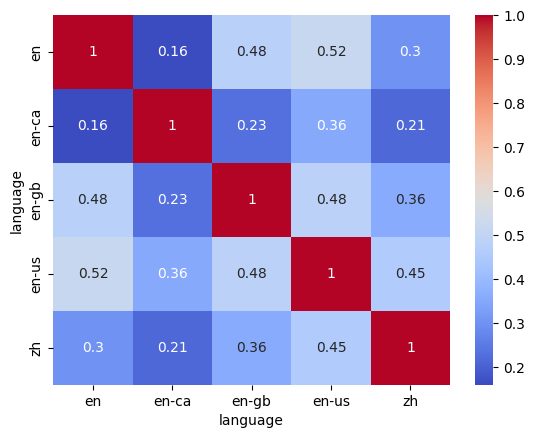

In [ ]:
sns.heatmap(corr_matrix_language, annot=True, cmap='coolwarm')

Розглянувши розрахунки коефіцієнта кореляції для мови, якою користуються клієнти, ми бачимо, що вся кореляція є прямою, частково помірною, частково низькою:
1. найсильніша мід американською англійською та англійською, а наслабша між канадською англійською та китайською.
2. Розглянувши значення p-value ми бачимо, що між канадською англійською та англійською кореляція відсутня, оскільки значення більше 0.05

In [ ]:
pivot_date_registration = df.pivot_table(
    index='date',
    columns='is_registration',
    values='price',
    aggfunc='sum'
).fillna(0)

print(pivot_date_registration)



is_registration  is registration  not registration
date                                              
2020-11-01               21547.0          222745.5
2020-11-02               44956.8          310550.0
2020-11-03               29150.5          469829.1
2020-11-04               20982.2          318204.9
2020-11-05               25334.6          365942.0
...                          ...               ...
2021-01-27               14613.6          271727.1
2021-01-28                   0.0               0.0
2021-01-29                   0.0               0.0
2021-01-30                   0.0               0.0
2021-01-31                   0.0               0.0

[92 rows x 2 columns]


In [ ]:
registered = pivot_date_registration['is registration']
guest = pivot_date_registration['not registration']
print(registered.describe())
print(guest.describe())

count       92.000000
mean     28070.853261
std      12124.817697
min          0.000000
25%      19938.250000
50%      27233.500000
75%      35478.600000
max      68151.100000
Name: is registration, dtype: float64
count        92.000000
mean     319447.963043
std      113764.392969
min           0.000000
25%      263005.700000
50%      315170.750000
75%      375010.750000
max      612358.400000
Name: not registration, dtype: float64


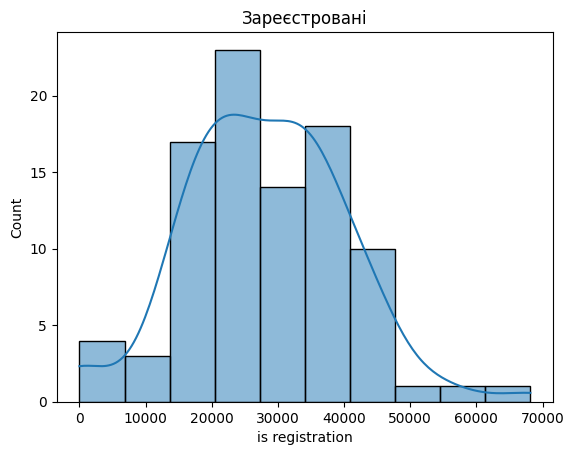

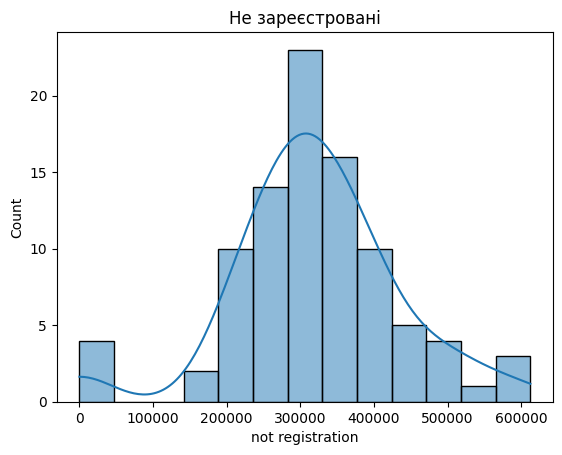

In [ ]:
sns.histplot(registered, kde=True)
plt.title('Зареєстровані')
plt.show()

sns.histplot(guest, kde=True)
plt.title('Не зареєстровані')
plt.show()

In [ ]:
from scipy.stats import shapiro

print(shapiro(registered))
print(shapiro(guest))

ShapiroResult(statistic=np.float64(0.9791680485530986), pvalue=np.float64(0.14816728286235686))
ShapiroResult(statistic=np.float64(0.9487769113384333), pvalue=np.float64(0.0012184604855253293))


In [ ]:
from scipy.stats import mannwhitneyu

mannwhitneyu(registered, guest, alternative='two-sided')

MannwhitneyuResult(statistic=np.float64(360.0), pvalue=np.float64(8.379540669190225e-27))

## Порівняння щоденних продажів зареєстрованих та незареєстрованих користувачів

1. Команду describe
  - ми бачимо, що у нас кількість продажів була однаковою, тобто не було днів коли були лише продажі по зареєстрованим або лише незареєстрованих користувачів.
  - порівняємо відмінності між середніми та медіанами по вибірках, оскільки суттїєвої різниці немає, можемо сказати що явного перекосу виборок вліво чи вправо немає
  - за значенням середнього відхилення ми бачимо, що серез зареєстрованих користувачів даний показник менший, тому можемо сказати, що взначення в вибірці мають менший розкит, тобто менше відрізняються від середнього
  - розглянувши мінімальні та максимальні значення по вибірках, ми можемо сказати, що за нашими даними є дні які були без продажів взагалі (можливо це недозавантажені дані, оскільки це останні дні в яких ми проводимо аналіз), при цьому слід зазначити, що серед незареєстрованих користувачів суми покупок більші тому і максимальне значення продажів більше
2. Побудуємо гісторгами, щоб наглядно оцінити розподіли:
 - для незареєстрованих користувачів графік вказує на нормальність розподілу
 - для зареєстрованих користувачів графік вказує на нормальність розподілу
3. Але, за графічним методом ми чітко сказати про нормальність розподілу вибірки для зареєстрованих користувачів не можемо, то проводимо тест Шапіро-Уілка:
 - pvalue=0.14816728286235686 -  для зареєстрованих користувачів, тому можемо сказати, що дана вибірка може вважатися нормальним
 - pvalue=0.0012184604855253293 -  для незареєстрованих користувачів, тому в даному випадку можемо сказати, що вибірка відрізняється від нормальної
4. Оскільки обидва розподіли не є нормальними, а лише один, для порівняння вибірок було використано тест Манна–Вітні.За результатами тесту отримано p-value = 8.379540669190225e-27, тобто так як p < 0.05: існує статистично значуща різниця між групами.

In [ ]:
pivot_date_channel_session = df.pivot_table(
    index='date',
    columns='channel',
    values='ga_session_id',
    aggfunc='count'
).fillna(0)

print(pivot_date_channel_session)

channel     Direct  Organic Search  Paid Search  Social Search  Undefined
date                                                                     
2020-11-01     608             920          706            214        128
2020-11-02     810            1242          970            315        262
2020-11-03    1216            1871         1367            392        327
2020-11-04     935            1425         1145            368        311
2020-11-05     845            1293          917            346        342
...            ...             ...          ...            ...        ...
2021-01-27     984            1561         1192            359        339
2021-01-28     997            1379         1107            364        265
2021-01-29     878            1319          988            288        227
2021-01-30     685             989          787            218        166
2021-01-31     644            1051          729            228        160

[92 rows x 5 columns]


In [ ]:
channels = pivot_date_channel_session.columns

samples = [pivot_date_channel_session[ch] for ch in channels]
for ch in channels:
    stat, p = shapiro(pivot_date_channel_session[ch])
    print(f"{ch}: p-value = {p}")

Direct: p-value = 0.034278771626201326
Organic Search: p-value = 0.012271774671209374
Paid Search: p-value = 0.010833125972481636
Social Search: p-value = 0.14127184979117535
Undefined: p-value = 0.054564615910193105


In [ ]:
from scipy.stats import kruskal

stat, p_value = kruskal(*samples)
print(p_value)

1.397036102599359e-78


Для аналізу кількості сесій за різними каналами трафіку я спочатку створила вибірки з даними. А саме порахувала кількість сесій по каналам за кожен день. далі за тестом Шапіро-Уілка перевіряємо вибірки на нормальність розподілу. Оскільки за даним тестом ми отримали наступні результати:
1. Direct: p-value = 0.034278771626201326 -  розподіл не є нормальним
2. Organic Search: p-value = 0.012271774671209374 -  розподіл не є нормальним
3. Paid Search: p-value = 0.010833125972481636 -  розподіл не є нормальним
4. Social Search: p-value = 0.14127184979117535 - вибірка з нормальним розподілом
5. Undefined: p-value = 0.054564615910193105 - вибірка з нормальним розподілом

Тобто надалі ми можемо обрати тест, лише який підходить якщо не всі вибірки мають нормальний розподіл, а саме Краскела–Уоліса.

За даним тестом ми отримали p_value < 0.05 , що свідчить про наявність статистично значущих відмінностей між каналами.


In [ ]:
filtered_df = df[df['continent'].isin(['Europe', 'Americas'])]

total_sessions = (
    filtered_df
    .groupby('continent')['ga_session_id']
    .count()
)
organic_sessions = (
    filtered_df[filtered_df['channel'] == 'Organic Search']
    .groupby('continent')['ga_session_id']
    .count()
)
total_sessions = total_sessions.reindex(['Europe', 'Americas'])
organic_sessions = organic_sessions.reindex(['Europe', 'Americas']).fillna(0)

In [ ]:
europe_org = organic_sessions['Europe']
americas_org = organic_sessions['Americas']

europe_total = total_sessions['Europe']
americas_total = total_sessions['Americas']

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

counts = [europe_org, americas_org]
nobs = [europe_total, americas_total]

stat, p_value = proportions_ztest(counts, nobs)

print(stat, p_value)

0.28951412926103953 0.7721879690501752


В даній частині я розрахувала чи відрізняється статистично доля сесій з органічним трафіком у Європі та Америці

Оскільки для розрахунків нам потрібно порівняти відсотки, а саме числа від 0 до 1, то ми обрали z-test.
За даними розрахунками ми отримали p_value = 0,77, що більше ніж 0,05, тобто можемо сказати що різниця між континентами долею сесій органічного каналу трафіку серед загальної кількості сесій в Америці та Європі не є статистично значущою.



In [ ]:
filtered_df_America = df[df['continent'].isin(['Americas'])]
filtered_df_not_America = df[df['continent'] != 'Americas']

total_sessions_America = filtered_df_America['ga_session_id'].count()
total_sessions_not_America = filtered_df_not_America['ga_session_id'].count()

print(total_sessions_America)
print(total_sessions_not_America)

total_sales_America = filtered_df_America['price'].sum()
total_sales_not_America = filtered_df_not_America['price'].sum()

print(total_sales_America)
print(total_sales_not_America)

193179
156366
17665280.0
14306451.1


Оскільки продажі в Америці являються найбільшими Порівняємо, чи є статистично значуща різниця між продажами в Америці та іншими континентами, а також між кількістю сесій в Америці та іншими континентами

In [ ]:

total_sessions_America = (
    filtered_df_America
    .groupby('date')['ga_session_id']
    .count()
).fillna(0)

total_sessions_not_America = (
    filtered_df_not_America
    .groupby('date')['ga_session_id']
    .count()
).fillna(0)

In [ ]:
print(shapiro(total_sessions_America))
print(shapiro(total_sessions_not_America))

ShapiroResult(statistic=np.float64(0.9707620270090751), pvalue=np.float64(0.036496947708252264))
ShapiroResult(statistic=np.float64(0.9656011399524224), pvalue=np.float64(0.015705526084332313))


In [ ]:
mannwhitneyu(total_sessions_America, total_sessions_not_America, alternative='two-sided')

MannwhitneyuResult(statistic=np.float64(6141.5), pvalue=np.float64(1.2587057304145373e-07))

In [ ]:
total_sales_America = (
    filtered_df_America
    .groupby('date')['price']
    .sum()
).fillna(0)

total_sales_not_America = (
    filtered_df_not_America
    .groupby('date')['price']
    .sum()
).fillna(0)

print(shapiro(total_sales_America))
print(shapiro(total_sales_not_America))

ShapiroResult(statistic=np.float64(0.9669532892072812), pvalue=np.float64(0.01954332601296497))
ShapiroResult(statistic=np.float64(0.9413187506508757), pvalue=np.float64(0.0004323176471834614))


In [ ]:
mannwhitneyu(total_sales_America, total_sales_not_America, alternative='two-sided')

MannwhitneyuResult(statistic=np.float64(5755.0), pvalue=np.float64(2.4984024551739412e-05))

Отже, проаналізувавши вибірки по кількості сесій в Америці, та інших країнах бачимо, що дані вибірки відрізняються від нормального розподілу. Так як провівши тест проводимо тест Шапіро-Уілка ми отримали p-value < 0.05.

Саме тому проводимо тест Манна–Вітні. За даним тестом ми отримали p-value < 0.05, тобто можемо сказати що різниця між вибірками є статистично значущою

Такі самі показники ми отрималми і при аналізі продажів з таким же самим розподілом.

https://public.tableau.com/app/profile/maryna.borysova/viz/SalesandSessions_17769518689940/SalesansSessions?publish=yes

#Висновок

**Загальні показники діяльності**:
- Кількість унікальних сесій 349545
- Період аналізу від 2020-11-01 до 2021-01-31
- Кількість унікальних категорій 14
- Кількість континентів 6
- Кількість країн 108
- Сума продажів склала 31679446 млн доларів
- Кількість зареєстрованих акаунтів 27945
- Коефіцієнт підтверджених емейлів 71,7%
- Коефіцієнт відписок 16,9%

Далі ми проводили аналіз у розрізі континентів, країн, категорій, девайсів, каналів.

**Рейтинги у розрізі продажів:**

##ТОП-5 країн:
1. Сполучені Штати Америки
2. Індія
3. Канада
4. Обєднане королівство
5. Франція

##ТОП-3 континента:
1. Америка
2. Азія
3. Європа

##ТОП-10 категорій:
1. Дивани та крісла
2. Стільці
3. Ліжка
4. Книжкові шафи та стелажі
5. Шафи та комоди
6. Садові меблі
7. Столи та парти
8. Комоди та комоди
9. Барні меблі
10. Дитячі меблі

 Найбільше продажів відбувається через Дестоп серед користувачів Chrome. Також слід зазначити, що найбільш популярним є органічний канал звязку. При цьому більшість продажів проводиться серед не зареєстрованих користувачів.

 **Аналіз залежностей (кореляцій)**

 1. Я виявила, що кількість продажів має сильну пряму кореляцію від кількості сесій, а саме 0,86.
 2. Кореляції між континентамми також являються високими та мають прямий звязок. Це може говорити про те, що компанія використовує однакову політику з продажів та види маркетингу для всіх континентів.
 3. Розглянувши кореляції між каналами звязку, то ми виявили, що скрізь вона має прямий звязок, при цьому високий рівень мають лише кореляції між:
- Direct - Organic Search
- Direct - Paid Search
- Organic Search - Paid Search
інші пари каналів мають середній рівень кореляції.
4. Розглянувши кореляції між мовами, якими користуються клієнти високого рівня не було виявлено, лише середній та низький, але напрямок скрізь прямий.

**Аналіз відмінності між групами:**

1. Порівнявши щоденні продажі користувачами я отримала статистично значущу різницю між зареєстрованими та незареєстрованими.
2. Між користувачами по різним каналам звязку є статистично значуща різниця.
3. Обравши канал звязку з найбільшою кількістю сесій, а саме Органічний, я порівняла долю сесій з органічним трафіком у Європі та Америці -  в даному випадку статистично значущої різниці не виявлено.
4. Розділивши континенти по продажам, а саме Америка - найбільші продажі та Європа, Азія, Африка, Океанія інші. Ми отриматили статистично значущу різницю між показниками продажів при даному типі розподілу.